# FastFarmStandaloneInterface: a Python-FastFarm interface for wind farm control

## Prerequisites

This notebook runs with a standard Python kernel (no MPI needed).
The `FastFarmStandaloneInterface` runs FAST.Farm as a subprocess.

In [1]:
# UNCOMMENT TO INSTALL WFCRL Kernel
#from wfcrl import jupyter_utils
#jupyter_utils.create_ipykernel()

A standard Python 3 kernel is sufficient (e.g., the `wfcrl` virtual environment kernel).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tempfile, os

from wfcrl.environments.data_cases import named_cases_dictionary
from wfcrl.interface import FastFarmStandaloneInterface

sns.set_theme(style="darkgrid")

## Farm configuration

In the following, it is assumed that you have a local FastFarm executable. Start by updating the path to this `exe` file below.

In [3]:
# Update this to point to your FAST.Farm v5.0.0 executable
FAST_FARM_EXECUTABLE = "simulators/fastfarm/bin/FAST.Farm_x64_OMP.exe"

The library comes with a list of pre-existing farm layouts that can be found in `environments/data_cases.py` and uses directly to create an interface:

In [4]:
# Pick any case from the dictionary: DafengH1, Ablaincourt, Turb6_Row2, etc.
CASE_NAME = "DafengH1"
farm_case = named_cases_dictionary[CASE_NAME + "_"][0]  # [0]=FAST.Farm, [1]=FLORIS

output_dir = os.path.join(tempfile.gettempdir(), "wfcrl_interface_demo")
config = farm_case.dict()
config["max_iter"] = 5
config["dt"] = 3
config["speed"] = 10

ff_interface = FastFarmStandaloneInterface(config, output_dir)
ff_interface.setup()
print(f"Case: {CASE_NAME} ({ff_interface.n_turbines} turbines)")
print(f"Files in: {ff_interface.farm_base}")

Deltas: [ 2.01534455e-03  2.00536760e-03  2.00536760e-03  2.00536760e-03
  2.00536760e-03  2.00536760e-03  2.00536760e-03  1.50651994e-03
  9.97695324e-04  4.88870709e-04  9.97695324e-04  9.97695324e-04
  9.97695324e-04  9.97695324e-04  9.97695324e-04  1.33691173e-03
  6.68455867e-04 -1.99539065e-05 -1.99539065e-05 -9.97695322e-06
 -9.97695322e-06 -9.97695324e-06  1.13242749e-14 -5.98617194e-05]
Exception has been raise. I put this print statement instead. Check with EB.
Exception: Some Y0_High are not on an integer multiple of the high-res grid
Created FAST.Farm input file: C:\Users\Freeman\AppData\Local\Temp\wfcrl_interface_demo/FarmInputs/Case.fstf
Case: DafengH1 (24 turbines)
Files in: C:\Users\Freeman\AppData\Local\Temp\wfcrl_interface_demo/FarmInputs


Alternatively, you can create your own layout with `FastFarmCase` and use `create_ff_case` to create all the configuration files needed to run FAST.Farm.

In [5]:
# Alternatively, create a custom layout (speed is set via dict, not constructor)
from wfcrl.environments.data_cases import FastFarmCase

custom_case = FastFarmCase(
    num_turbines=3,
    xcoords=[0.0, 504.0, 1008.0],
    ycoords=[0.0, 0.0, 0.0],
    dt=3, max_iter=10, t_init=0,
)
custom_config = custom_case.dict()
custom_config["speed"] = 10  # set wind speed after construction

custom_dir = os.path.join(tempfile.gettempdir(), "wfcrl_custom_demo")
ff_custom = FastFarmStandaloneInterface(custom_config, custom_dir)
ff_custom.setup()
print(f"Custom case files in: {ff_custom.farm_base}")

Created FAST.Farm input file: C:\Users\Freeman\AppData\Local\Temp\wfcrl_custom_demo/FarmInputs/Case.fstf
Custom case files in: C:\Users\Freeman\AppData\Local\Temp\wfcrl_custom_demo/FarmInputs


Then, make the FAST.Farm interface with the created file or your own `.fstf`.

In [6]:
# The interface is ready. The simulation files are in:
#   ff_interface.farm_base  (FarmInputs directory)
#   ff_interface.fstf_file  (main .fstf input file)
print(f"FAST.Farm input: {ff_interface.fstf_file}")
print(f"Turbines: {ff_interface.n_turbines}")

# To run the simulation and parse results:
# measurements = ff_interface.run()
# See example_hycon_farm_control.py for full usage.

FAST.Farm input: C:\Users\Freeman\AppData\Local\Temp\wfcrl_interface_demo/FarmInputs/Case.fstf
Turbines: 24


The case files are generated in a temporary directory. The .fstf file and all turbine input files are ready for FAST.Farm simulation. Results are parsed automatically when calling `ff_interface.run()`.

## Start simulation

Set yaw and pitch angles, then run the simulation. The interface automatically generates input files, runs FAST.Farm, and parses the output.

In [7]:
# Run simulation and collect measurements
# Note: FastFarmStandaloneInterface runs FAST.Farm as a subprocess
# and parses the output .outb files. For real-time control,
# see FastFarmOnlineInterface in wfcrl.interface instead.

ff_interface.set_yaw_pitch(0.0, 0.0)  # yaw=0, pitch=0 for all turbines
measurements = ff_interface.run()

if measurements['power_mw'] is not None:
    time_vec = measurements['time']
    power_mw = measurements['power_mw']
    farm_power = power_mw.sum(axis=1)
    print(f"Simulation completed: {len(time_vec)} time steps")
    print(f"Farm power range: {farm_power.min():.2f} - {farm_power.max():.2f} MW")
else:
    print("No power data collected")

Simulation completed: 151 time steps
Farm power range: 38.59 - 74.48 MW


## Plots and data

All the measurements are available with the method `get_all_measures()` and stored in `raw_measures` in our case.

In [8]:
# Show per-turbine power at the last time step
if measurements['power_mw'] is not None:
    df_power = pd.DataFrame({
        'turbine': [f"T{i+1}" for i in range(ff_interface.n_turbines)],
        'power_MW': measurements['power_mw'][-1, :] if measurements['power_mw'].ndim > 1 else measurements['power_mw']
    })
    df_power

In [9]:
# Create a DataFrame with all power data for plotting
if measurements['power_mw'] is not None:
    n_turb = measurements['power_mw'].shape[1]
    cols = [f"T{i+1}_power_MW" for i in range(n_turb)]
    df = pd.DataFrame(measurements['power_mw'], columns=cols)
    df["time_s"] = measurements['time']
    df["total_MW"] = df.sum(axis=1)

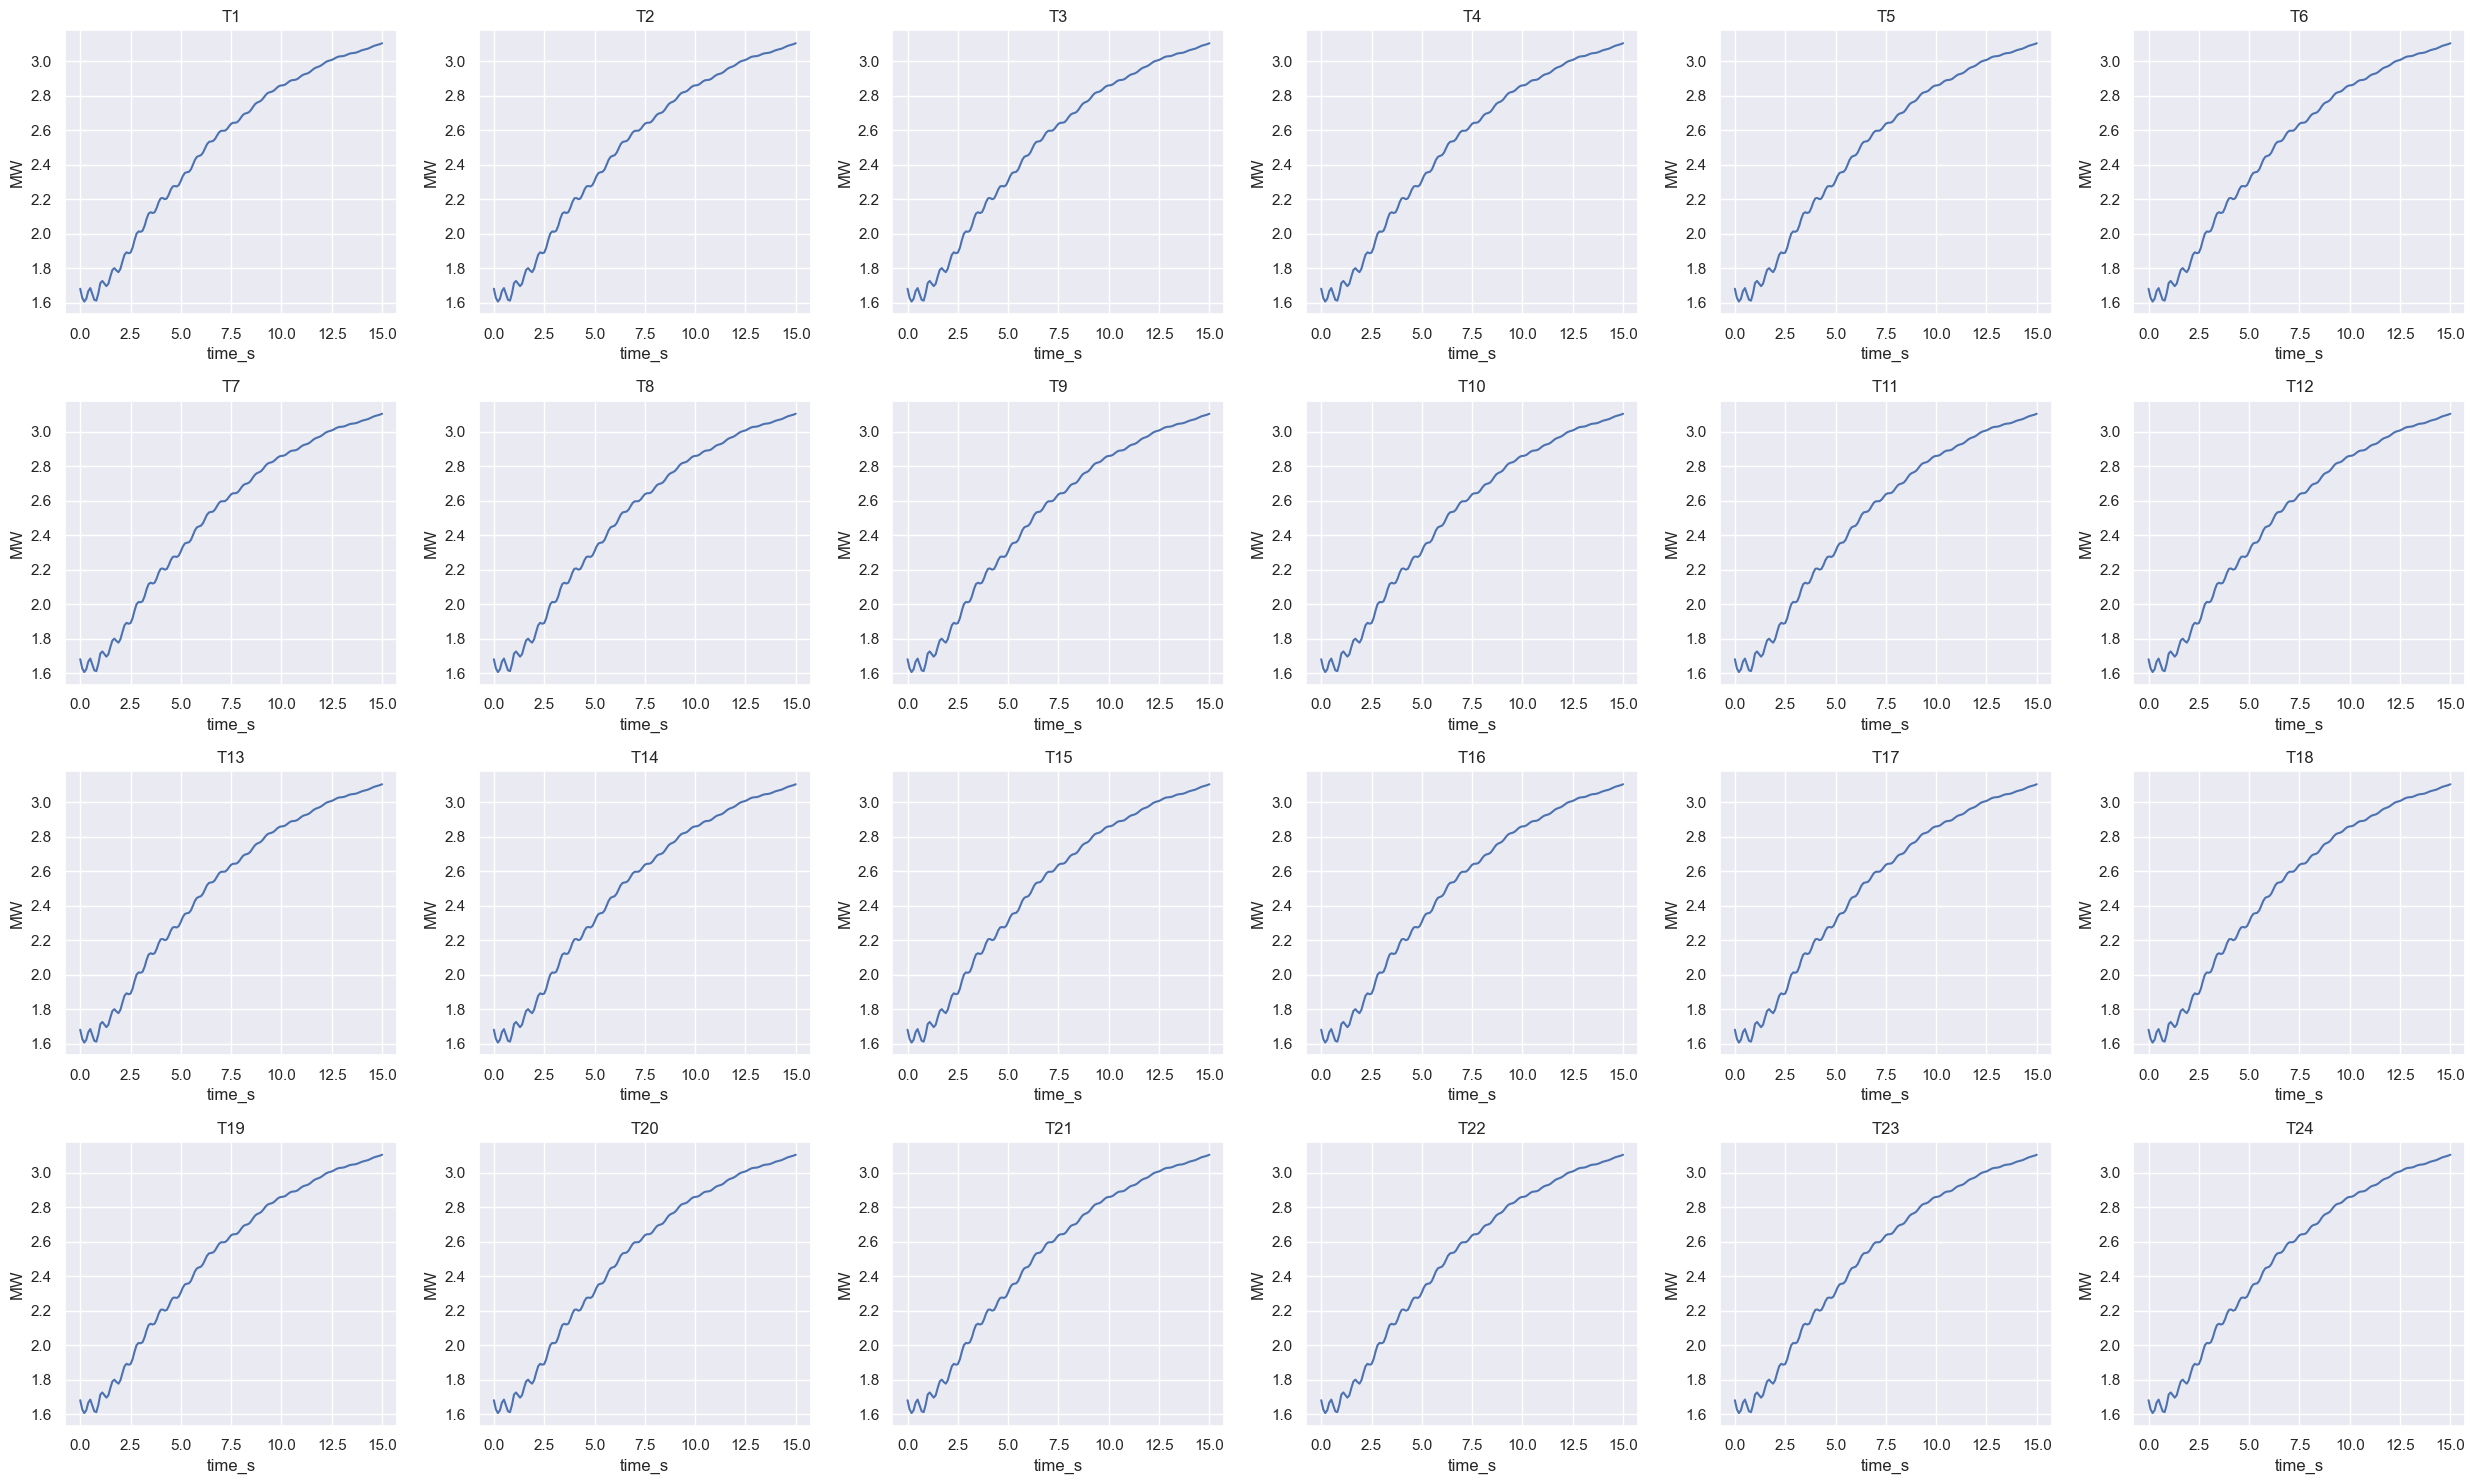

In [10]:
# Plot individual turbine power and total farm power
if 'df' in locals():
    fig, axes = plt.subplots(nrows=4, ncols=6, figsize=(25, 15))
    for i, ax in enumerate(axes.flatten()):
        if i < ff_interface.n_turbines:
            col = f"T{i+1}_power_MW"
            sns.lineplot(df, x="time_s", y=col, ax=ax)
            ax.set_title(f"T{i+1}")
            ax.set_ylabel("MW")
        else:
            ax.set_visible(False)
    plt.tight_layout()

Power measurements are returned as a numpy array from `measurements['power_mw']`, with shape (n_time_steps, n_turbines). The time vector is in `measurements['time']`. Use `import wfcrl.interface.FastFarmOnlineInterface` for step-by-step online optimization.

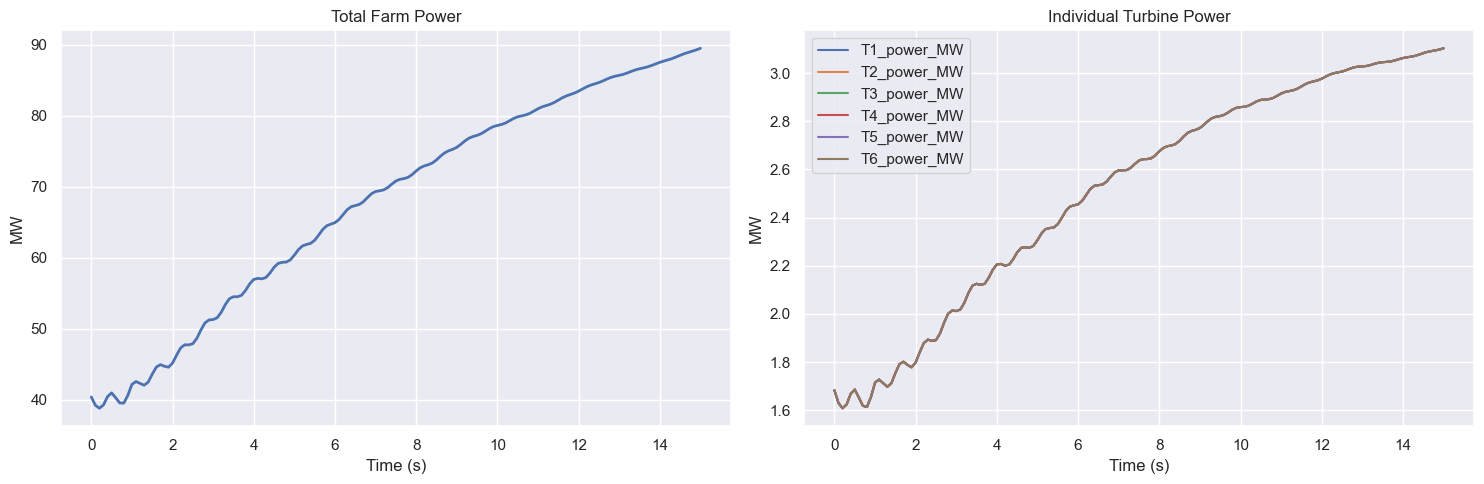

In [12]:
# Plot farm total power and turbine powers
if 'df' in locals():
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
    axes[0].plot(df["time_s"], df["total_MW"], 'b-', lw=2)
    axes[0].set(xlabel="Time (s)", ylabel="MW", title="Total Farm Power")

    # First 6 turbines - melt for seaborn
    plot_cols = [c for c in df.columns if c.startswith("T")][:6]
    df_melt = df.melt(id_vars=["time_s"], value_vars=plot_cols,
                      var_name="Turbine", value_name="Power_MW")
    sns.lineplot(df_melt, x="time_s", y="Power_MW", hue="Turbine", ax=axes[1])
    axes[1].set(xlabel="Time (s)", ylabel="MW", title="Individual Turbine Power")
    axes[1].legend(loc='best')
    plt.tight_layout()